# Model Training for Anomaly Detection

## Purpose of This Notebook

This notebook implements the **model training stage** for the anomaly detection pipeline.

Its purpose is to:

- Generate synthetic QR scan data with anomalies,
- Train an Isolation Forest model for anomaly detection,
- Save the trained model for use in the consumer stage.

This notebook represents the **offline training phase** of the system.

---

## Data Generation

Synthetic QR scan data is generated with features similar to the original QR Phishing detection:

- `hour`: Time of scan (mostly work hours for normal)
- `url_length`: Length of the URL
- `dot_count`: Number of dots in the URL
- `protocol`: HTTP or HTTPS

Anomalies (phishing attempts) are introduced with:
- Late night hours
- Very long URLs
- Many dots
- HTTP protocol

---

## Model Training

An Isolation Forest is trained on the normal data to learn what typical QR scans look like.

The model is then saved to a file for use in the real-time consumer.

---

## Output

- Trained Isolation Forest model saved as `isolation_forest_model.pkl`
- Scaler and encoder saved as `scaler.pkl` and `encoder.pkl`
- Training results and visualizations

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

In [2]:
# 1. Create Synthetic QR Scan Data
n_samples = 10000  # Larger dataset for better training
data = {
    'hour': np.random.randint(8, 18, n_samples),  # Most scans during work hours
    'url_length': np.random.normal(25, 5, n_samples).astype(int),
    'dot_count': np.random.randint(1, 3, n_samples),
    'protocol': np.random.choice(['https', 'http'], n_samples, p=[0.9, 0.1]),
    'label': 0  # Normal
}

df = pd.DataFrame(data)

# 2. Add Anomalies (Phishing Attacks)
n_attacks = 300  # 3% anomalies
df.loc[:n_attacks-1, 'hour'] = np.random.randint(0, 5, n_attacks)  # Late night
df.loc[:n_attacks-1, 'url_length'] = np.random.randint(80, 150, n_attacks)  # Long URLs
df.loc[:n_attacks-1, 'dot_count'] = np.random.randint(5, 10, n_attacks)  # Many dots
df.loc[:n_attacks-1, 'label'] = 1  # Malicious

print(f"Training dataset ready with {len(df)} rows. Anomaly rate: {n_attacks/n_samples*100}%")
df.head()

Training dataset ready with 10000 rows. Anomaly rate: 3.0%


,hour,url_length,dot_count,protocol,label
0,1,142,7,http,1
1,0,125,7,https,1
2,3,122,7,https,1
3,1,83,8,https,1
4,4,104,8,https,1


In [3]:
# Show basic stats
print("Dataset Statistics:")
print(df.describe())

# Check the distribution of normal (0) vs malicious (1)
print("\nClass Distribution:")
print(df['label'].value_counts(normalize=True) * 100)

Dataset Statistics:
              hour    url_length     dot_count         label
count  10000.00000  10000.000000  10000.000000  10000.000000
mean      12.16840     27.249400      1.654000      0.030000
std        3.33328     16.620584      1.094259      0.170596
min        0.00000      5.000000      1.000000      0.000000
25%       10.00000     21.000000      1.000000      0.000000
50%       12.00000     25.000000      2.000000      0.000000
75%       15.00000     28.000000      2.000000      0.000000
max       17.00000    149.000000      9.000000      1.000000

Class Distribution:
label
0    97.0
1     3.0
Name: proportion, dtype: float64


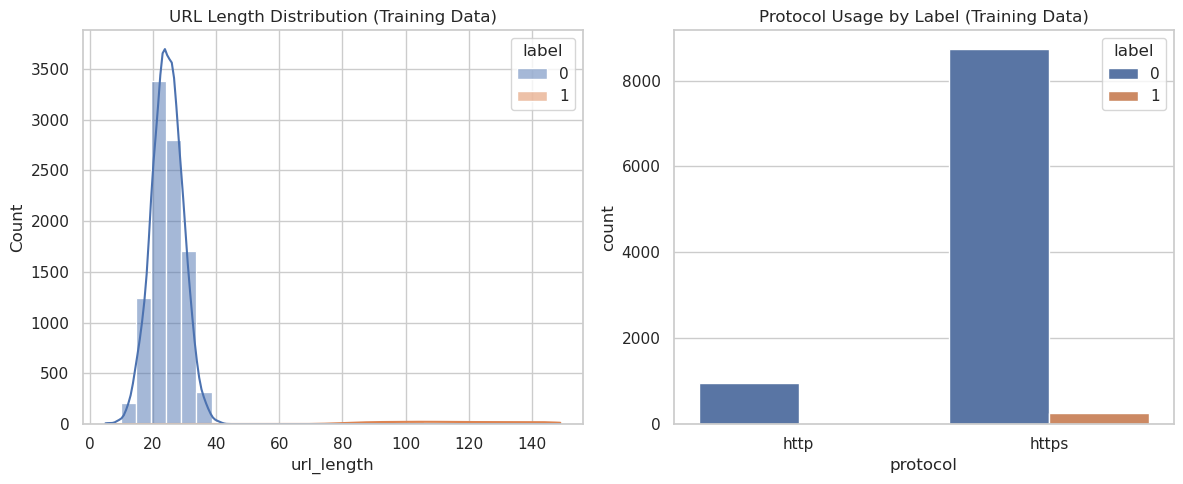

In [4]:
# Visualization of training data
plt.figure(figsize=(12, 5))

# Visualization 1: Histogram of URL Lengths colored by Label
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='url_length', hue='label', bins=30, kde=True)
plt.title('URL Length Distribution (Training Data)')

# Visualization 2: Count of Protocols used
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='protocol', hue='label')
plt.title('Protocol Usage by Label (Training Data)')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest

# Copy the dataframe to keep the original safe
df_model = df.copy()

# Encode categorical feature (protocol)
le = LabelEncoder()
df_model['protocol'] = le.fit_transform(df_model['protocol'])

# Scale the numeric features (hour, url_length, dot_count)
scaler = StandardScaler()
features = ['hour', 'url_length', 'dot_count', 'protocol']
df_model[features] = scaler.fit_transform(df_model[features])

In [6]:
# 1. Initialize the model
iso_forest = IsolationForest(contamination=0.03, random_state=42)

# 2. Fit the model on the training data
iso_forest.fit(df_model[features])

# 3. Predict on training data to evaluate
df['anomaly_score'] = iso_forest.decision_function(df_model[features])
df['predicted_label'] = iso_forest.predict(df_model[features])

# 4. Convert -1/1 to 1/0 to match our original labels
df['predicted_label'] = df['predicted_label'].map({1: 0, -1: 1})

print("Model training complete!")

Model training complete!


Model detected 300 anomalies out of 10000 training samples.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9700
           1       1.00      1.00      1.00       300

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



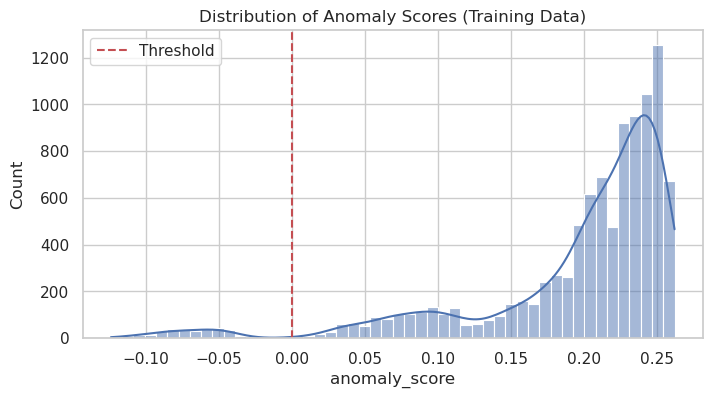

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

# Report how many anomalies were detected in training
detected_count = df['predicted_label'].sum()
print(f"Model detected {detected_count} anomalies out of {len(df)} training samples.")

# Show metrics
print("\nClassification Report:")
print(classification_report(df['label'], df['predicted_label']))

# Visualize Anomaly Scores
plt.figure(figsize=(8, 4))
sns.histplot(df['anomaly_score'], bins=50, kde=True)
plt.axvline(x=0, color='r', linestyle='--', label='Threshold')
plt.title('Distribution of Anomaly Scores (Training Data)')
plt.legend()
plt.show()

In [8]:
# Save the trained model and preprocessing objects
with open('isolation_forest_model.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model and preprocessing objects saved successfully!")
print("- isolation_forest_model.pkl")
print("- scaler.pkl")
print("- encoder.pkl")

Model and preprocessing objects saved successfully!
- isolation_forest_model.pkl
- scaler.pkl
- encoder.pkl
